<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17_1_4_SLR_Influence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: Influence, Leverage, and Cook's Distance

Author: Brad Sheese

---

## What This Notebook Is About

In Notebook 17_1_3 we learned to check the LINE assumptions by looking at the *overall shape* of the residuals. That's the right tool for checking whether a model is broken *as a whole*.

But sometimes the model is mostly fine, and a **single row of your dataset** is doing all the damage. One bad house, one mis-typed number — and your slope, $R^2$, and p-value all go haywire. The summary table won't tell you. The LINE diagnostics won't pinpoint it.

This notebook is about the specific accusation. We'll learn to answer:

> **Which specific rows are actually moving my regression line — and by how much?**

Three concepts must be pulled apart:

| Term | Meaning | Which axis is weird |
|---|---|---|
| **Leverage** | The point has an unusual $x$ value | $x$ |
| **Outlier** | The point has an unusual $y$ value (big residual) | $y$ |
| **Influence** | Removing this point would meaningfully move the line | *both* |

A point can be an outlier without being influential. A point can have high leverage without being influential. The points that really hurt are those with **high leverage *and* a large residual** — and a single number catches exactly those: **Cook's Distance**.

We'll use **Ames Housing** from 17_0_5 and poison it with one fake row to give ourselves a villain to hunt.

## Setup

We reload Ames Housing — 2,930 homes with `area` predicting `price` (thousands of dollars). Then we inject one fake row: a 10,000-square-foot mansion that allegedly sold for \$500.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import urllib.request
import statsmodels.api as sm
from sklearn.linear_model import HuberRegressor

sns.set_style('whitegrid')
rng = np.random.default_rng(seed=42)

# Ames Housing (needs custom headers; plain pd.read_csv(url) returns 406).
url = 'https://raw.githubusercontent.com/bsheese/cs377/main/data/ames_openintro.csv'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36', 'Accept': 'text/csv,*/*'})
with urllib.request.urlopen(req) as resp:
    ames = pd.read_csv(io.BytesIO(resp.read()))
ames = ames[['area', 'price']].copy()
ames['price'] = ames['price'] / 1000.0

# Inject one poisoned row: 10,000 sq ft, $500.
poison_row = pd.DataFrame({'area': [10_000], 'price': [0.5]})
ames = pd.concat([ames, poison_row], ignore_index=True)

print(f'Total rows after poisoning: {len(ames)}')

Total rows after poisoning: 2931


In [2]:
X = sm.add_constant(ames['area'])
y = ames['price']
model_bad = sm.OLS(y, X).fit()

print(f'Slope     : {model_bad.params["area"]:.4f} $K per sq ft')
print(f'Intercept : {model_bad.params["const"]:.2f} $K')
print(f'R^2       : {model_bad.rsquared:.4f}')

Slope     : 0.1000 $K per sq ft
Intercept : 30.48 $K
R^2       : 0.4383


Compare that $R^2$ to the clean dataset from 17_0_5: **0.50**. On the poisoned dataset it dropped to **0.44** — a sizable hit from *one row out of 2,931*. The slope changed too (0.100 vs. roughly 0.112). Our regression has been mugged by a single row.

We *did* tell you the poisoned row is there. In a real pipeline you might not know. The rest of this notebook builds the tools to find it — and more importantly, to find subtler problems you couldn't have spotted by glancing at the data.

---

## Section 1: Three Distinct Problems — Vocabulary First

Before we look at any real data, three easily-confused terms need to be clearly separated:

| Term | Meaning | Which axis is unusual |
|---|---|---|
| **Leverage** | The point has an unusual $x$ value | $x$ |
| **Outlier** | The point has an unusual $y$ value (big residual) | $y$ |
| **Influence** | Removing this point would meaningfully move the line | *both* |

A high-leverage point is not automatically a problem — if it agrees with the extrapolated trend, it can actually strengthen the fit. A big residual is not automatically damaging either — if it sits near the average $x$, it can barely move the slope. What *is* dangerous is a point with **high leverage AND a large residual**: extreme $x$, and a $y$ that disagrees with where the trend would put it.

> **Moral: influence = leverage × disagreement.** Cook's Distance captures this product in a single number.

The four panels below demonstrate each case on a tiny toy dataset — same 20 clean points, different contaminating point in the last three.

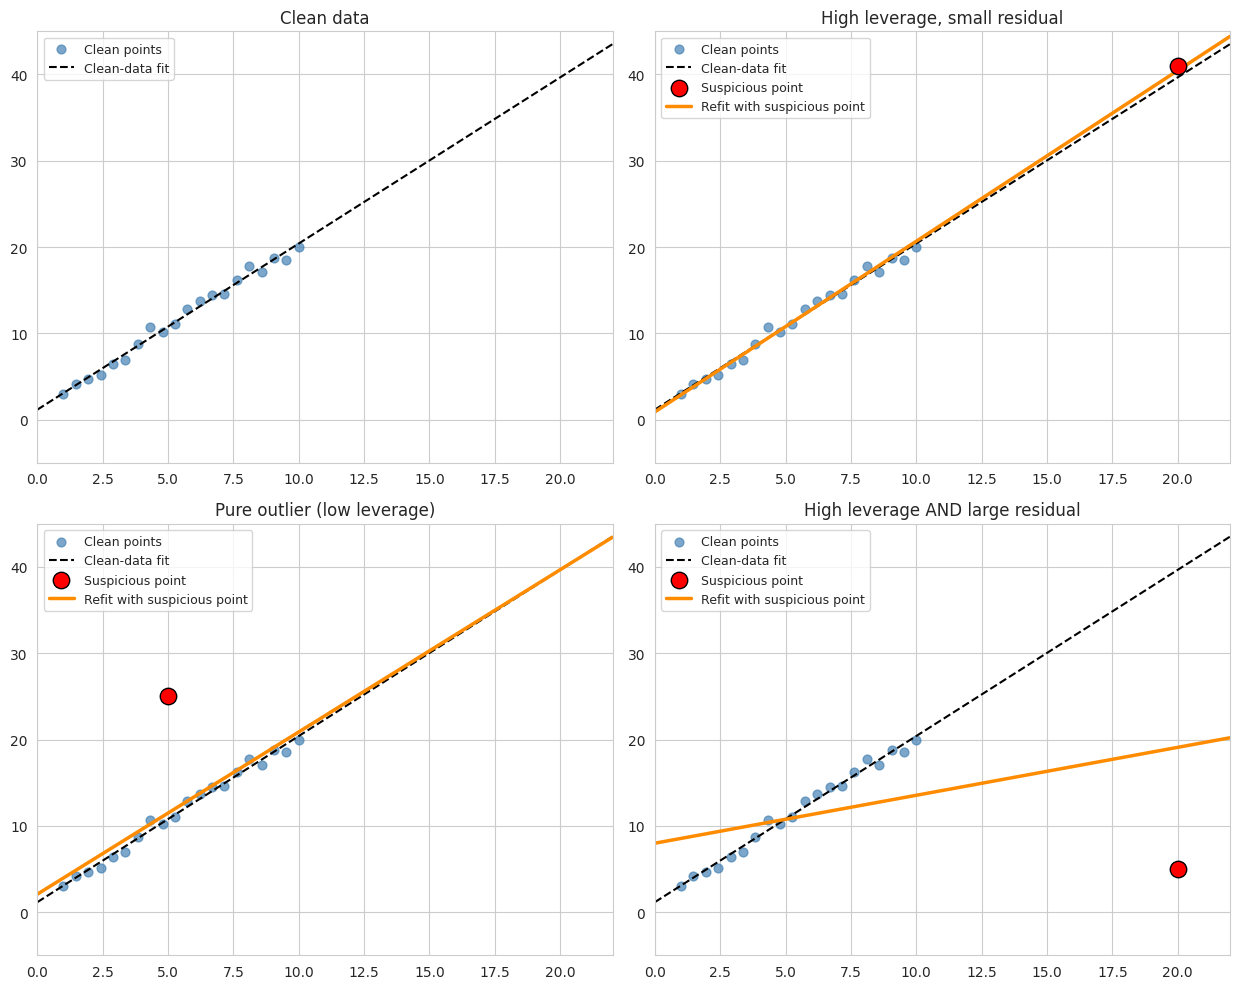

In [3]:
toy_rng = np.random.default_rng(seed=7)   # local seed — independent of run order
x_toy = np.linspace(1, 10, 20)
y_toy = 2 * x_toy + 1 + toy_rng.normal(0, 0.8, size=20)

def fit_line(x_data, y_data):
    return sm.OLS(y_data, sm.add_constant(x_data)).fit()

scenarios = [
    {'title': 'Clean data',                       'extra': None},
    {'title': 'High leverage, small residual',    'extra': (20, 41)},
    {'title': 'Pure outlier (low leverage)',      'extra': (5, 25)},
    {'title': 'High leverage AND large residual', 'extra': (20, 5)},
]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 10))
clean_model = fit_line(x_toy, y_toy)
x_line = np.linspace(0, 22, 100)

for ax, scen in zip(axes.flatten(), scenarios):
    ax.scatter(x_toy, y_toy, s=40, color='steelblue', alpha=0.7, label='Clean points')
    ax.plot(x_line, clean_model.predict(sm.add_constant(x_line)),
            color='black', linestyle='--', linewidth=1.5, label='Clean-data fit')

    if scen['extra'] is not None:
        xe, ye = scen['extra']
        ax.scatter([xe], [ye], s=140, color='red', edgecolor='black',
                   zorder=5, label='Suspicious point')
        x_all = np.append(x_toy, xe)
        y_all = np.append(y_toy, ye)
        m = fit_line(x_all, y_all)
        ax.plot(x_line, m.predict(sm.add_constant(x_line)),
                color='darkorange', linewidth=2.5, label='Refit with suspicious point')

    ax.set_xlim(0, 22)
    ax.set_ylim(-5, 45)
    ax.set_title(scen['title'])
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

What each panel does to the orange line relative to the black reference:

- **Top-left (clean).** No contamination; orange = black.
- **Top-right (high leverage, small residual).** The red point is far to the right (extreme $x$), but it agrees with the extrapolated trend. The orange and black lines overlap. **High leverage alone is not a problem** for the slope — though it *can* still inflate standard errors.
- **Bottom-left (pure outlier, low leverage).** Normal $x$, wildly high $y$. Yet the orange line barely moves. **A big residual alone is not very damaging** when it sits near the average $x$.
- **Bottom-right (high leverage AND large residual).** Same extreme $x$ as panel two, but now $y$ is far below the extrapolated line. The orange line tilts sharply. **This is the dangerous combination.**

Our poisoned Ames row is textbook bottom-right: a house far outside the normal size range, with a price that pulls the regression line away from every other observation.

---

## Section 2: The Needle in the Haystack

With vocabulary in hand, we can ask the right question about our Ames dataset: which of those four panels does our poisoned row fall into?

We deliberately injected a point so extreme — 10,000 sq ft for \$500 — that it should be unmistakable. That's intentional: an obvious injection makes the Cook's Distance spike easy to see and verify against a known ground truth. Real problematic points are usually subtler (a plausible square footage, a price that's merely *off* rather than absurd). The diagnostic principles are the same; the practical challenge is that in realistic data, no single scatter plot reliably reveals them.

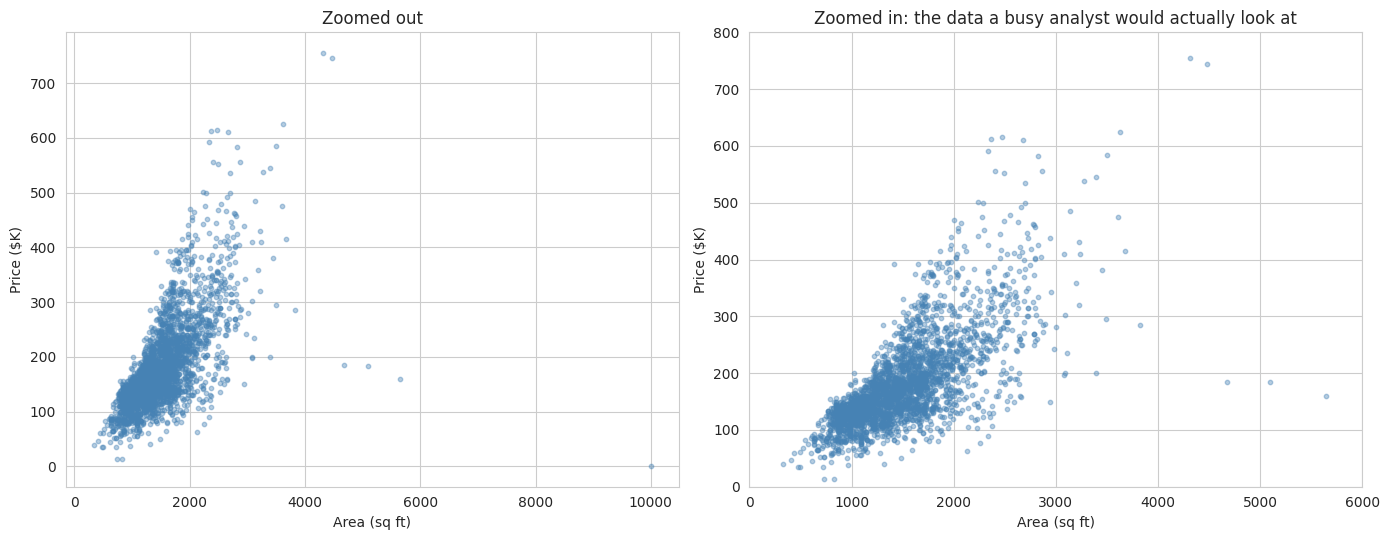

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(ames['area'], ames['price'], s=10, alpha=0.4, color='steelblue')
axes[0].set_xlabel('Area (sq ft)')
axes[0].set_ylabel('Price ($K)')
axes[0].set_title('Zoomed out')

axes[1].scatter(ames['area'], ames['price'], s=10, alpha=0.4, color='steelblue')
axes[1].set_xlim(0, 6000)
axes[1].set_ylim(0, 800)
axes[1].set_xlabel('Area (sq ft)')
axes[1].set_ylabel('Price ($K)')
axes[1].set_title('Zoomed in: the data a busy analyst would actually look at')

plt.tight_layout()
plt.show()

The extreme injection is visible in the zoomed-out view — we made it that way on purpose, so we can compare the diagnostic output against a known ground truth. The zoomed-in view (what an analyst would normally look at) shows nothing: a reasonable-looking cloud of houses with a clear positive trend.

In realistic settings, the influential point would be at a plausible $x$-value. No single scatter plot would flag it. Across dozens of features and thousands of rows, manual inspection fails entirely.

> **We need algorithms that examine every row's leverage and residual simultaneously. That is what influence diagnostics are for.**

---

## Section 3: Hunting in Ames with `.get_influence()`

> **One prerequisite:** influence diagnostics assume the model is reasonably well-specified. If the LINE assumptions from 17_1_3 are violated — especially linearity — Cook's Distance will flag points with large residuals that are large *because the model shape is wrong*, not because the data is bad. Always run LINE diagnostics first, then hunt for influence.

Statsmodels computes all three diagnostics from a single call: `model.get_influence()`.

In [5]:
influence = model_bad.get_influence()

leverages     = influence.hat_matrix_diag
stud_resids   = influence.resid_studentized_external
cooks_d, _    = influence.cooks_distance

print(f'Largest leverage:          {leverages.max():.4f}')
print(f'Most extreme studentized residual: {np.abs(stud_resids).max():.2f}')
print(f'Largest Cook\'s Distance:  {cooks_d.max():.3f}')

Largest leverage:          0.0883
Most extreme studentized residual: 19.08
Largest Cook's Distance:  15.695


One row towers above all others on every metric. Let's see it visually. Stem plots make spikes impossible to miss.

A note on the term "studentized": it comes from "Student" — the pen name of W.S. Gosset, the statistician who discovered the t-distribution. A studentized residual follows a t-distribution, so "studentized" essentially means "converted to a t-statistic."

Notice the pattern: a studentized residual is to a single data point what the **t-statistic** from 17_1_2 is to the slope — both measure "how many standard errors from zero."

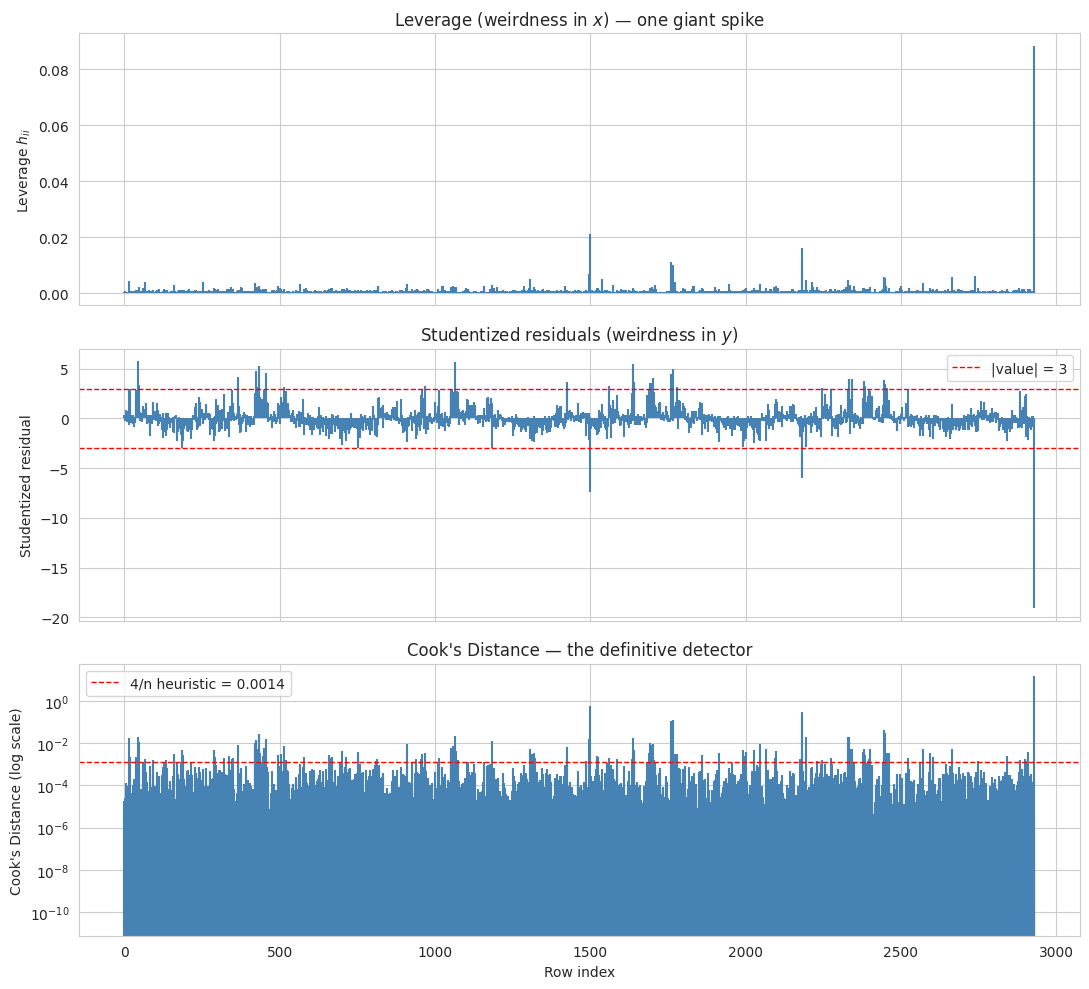

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

axes[0].stem(leverages, markerfmt=' ', basefmt=' ', linefmt='steelblue')
axes[0].set_ylabel('Leverage $h_{ii}$')
axes[0].set_title('Leverage (weirdness in $x$) — one giant spike')

axes[1].stem(stud_resids, markerfmt=' ', basefmt=' ', linefmt='steelblue')
axes[1].axhline(3, color='red', linestyle='--', linewidth=1, label='|value| = 3')
axes[1].axhline(-3, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('Studentized residual')
axes[1].set_title('Studentized residuals (weirdness in $y$)')
axes[1].legend()

# 4/n is a common heuristic; at large n it flags many unremarkable points — see cell below.
threshold = 4 / len(ames)
axes[2].stem(cooks_d, markerfmt=' ', basefmt=' ', linefmt='steelblue')
axes[2].axhline(threshold, color='red', linestyle='--', linewidth=1,
                label=f'4/n heuristic = {threshold:.4f}')
axes[2].set_yscale('log')
axes[2].set_ylabel("Cook's Distance (log scale)")
axes[2].set_xlabel('Row index')
axes[2].set_title("Cook's Distance — the definitive detector")
axes[2].legend()

plt.tight_layout()
plt.show()

All three diagnostics — and the influence plot — converge on the same row. The Cook's Distance spike is orders of magnitude above every other observation.

### Cook's Distance in one sentence

> **Cook's Distance for row $i$ measures how much every prediction in the dataset would change if we deleted row $i$ and refit the model.**

### On thresholds

The threshold $4/n$ is a common heuristic — not a mathematical law, and not always useful. With **large $n$** like our 2,931 rows, $4/n \approx 0.0014$: so small that many unremarkable points clear it and it loses diagnostic value. At small $n$ (say, 30), $4/n = 0.13$ is a more reasonable bar.

In practice, the most reliable approach at any sample size is to **look at the distribution of Cook's D values** — identify rows with values substantially larger than the bulk of the data. A spike, a gap, a clear outlier in the Cook's D values themselves is more informative than any fixed threshold. Other thresholds in the literature include $4/(n-k-1)$, $1.0$, and the $F_{0.5}$ percentile. None is canonical.

> **Investigate rows that stand out in the distribution. Never treat a threshold as a binary delete/keep rule.**

If Cook's Distance is the only diagnostic you remember from this notebook, you've got 90% of what you need.

### Finding the suspect programmatically

In a real investigation we wouldn't know which row is the culprit. We'd rank rows by Cook's Distance.

In [7]:
diagnostics = ames.copy()
diagnostics['cooks_d'] = cooks_d
diagnostics['leverage'] = leverages
diagnostics['stud_resid'] = stud_resids

diagnostics.sort_values('cooks_d', ascending=False).head(5)

,area,price,cooks_d,leverage,stud_resid
2930,10000,0.50,15.694687,0.088322,-19.083637
1498,5642,160.00,0.582641,0.021219,-7.398459
2180,5095,183.85,0.293016,0.016066,-6.026892
2181,4676,184.75,0.176808,0.012612,-5.285792
1767,4316,755.00,0.121721,0.009986,4.932344


The top row — 10,000 sq ft for \$0.5K — is the poisoned one. Its Cook's Distance is roughly 27× any legitimate data point. **In a production pipeline, this is the moment you page a human.** A 10,000 sq ft house is physically plausible; a \$500 sale price is not. A quick search would reveal it's an error, giving legitimate grounds to exclude it.

But before we do that — we need to talk about *when* you're allowed to drop data.

---

## Section 4: The Ethics of Dropping Data

This matters because Cook's Distance can be **catastrophically misused**. The temptation: you fit a model, the $R^2$ is disappointing, you run `get_influence()`, identify "the outliers," drop them, and suddenly the numbers look great. You ship the model. You publish the paper.

**Do not do this.**

Here is the rule that separates legitimate data cleaning from statistical fraud:

> **A high Cook's Distance is a reason to *investigate*, never a reason to *delete*.**

### You *are* allowed to remove a row if investigation reveals a concrete reason it doesn't belong:

- **Data entry error.** Our poisoned $500 mansion. Someone typed `500` when they meant `500,000`.
- **Wrong unit.** A temperature logged in Fahrenheit in a Celsius column.
- **Instrument failure.** A sensor stuck at zero.
- **Different population.** A commercial warehouse in a dataset of single-family homes.
- **Test observation.** A known dummy row that was never meant for training.

### You are **not** allowed to remove a row for:

- **"It was hurting my $R^2$."** That's what influence *means*. Deleting every point that hurts your fit gives you a model of a fantasy world.
- **"It was flagged by Cook's Distance."** Cook's tells you which rows *could* be problematic. It does not tell you they *are* problematic.
- **"The instructor / client / referee wanted a higher $R^2$."** No.

> **Cook's Distance is a detective, not an executioner.** It points at a suspect. You still have to investigate.

### What to do with genuinely influential points you can't legitimately drop

Sometimes you're stuck with a real data point that happens to be influential — not an error, just unusual. You have three professional options:

1. **Report results both with and without the influential point.** Transparent and honest; the gold standard for papers.
2. **Use robust regression.** Methods like Huber regression explicitly down-weight points with large residuals. We'll demonstrate this below.
3. **Model what's actually going on.** If a handful of points are genuinely different (e.g., mansions behave differently from regular homes), maybe you need separate models or an extra feature.

---

## Section 5: The Drop Test (and Alternatives)

With the ethics framework in place, we can now legitimately remove our poisoned row — because we identified a concrete data-entry error. Let's see what changes.

In [8]:
poison_idx = len(ames) - 1
ames_clean = ames.drop(index=poison_idx).reset_index(drop=True)

X_clean = sm.add_constant(ames_clean['area'])
y_clean = ames_clean['price']
model_clean = sm.OLS(y_clean, X_clean).fit()

comparison = pd.DataFrame({
    'With poisoned': [model_bad.params['area'],   model_bad.bse['area'],
                       model_bad.params['const'],   model_bad.rsquared],
    'Without':       [model_clean.params['area'], model_clean.bse['area'],
                       model_clean.params['const'], model_clean.rsquared],
}, index=['Slope (per sq ft)', 'SE of slope', 'Intercept ($K)', '$R^2$'])

comparison.round(4)

,With poisoned,Without
Slope (per sq ft),0.1000,0.1117
SE of slope,0.0021,0.0021
Intercept ($K),30.4800,13.2896
$R^2$,0.4383,0.4995


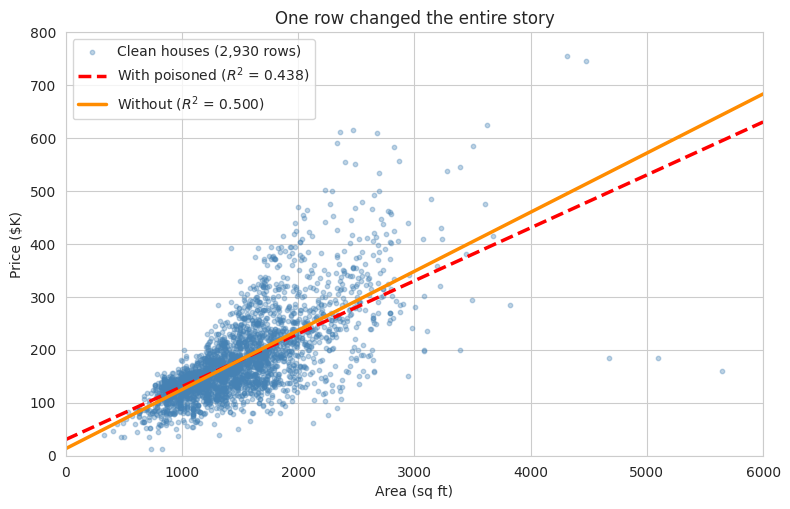

In [9]:
x_grid = np.linspace(0, 6000, 200)
y_bad = model_bad.predict(sm.add_constant(x_grid))
y_clean_line = model_clean.predict(sm.add_constant(x_grid))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(ames_clean['area'], ames_clean['price'], s=10, alpha=0.35, color='steelblue',
           label='Clean houses (2,930 rows)')
ax.plot(x_grid, y_bad, color='red', linewidth=2.5, linestyle='--',
        label=f'With poisoned ($R^2$ = {model_bad.rsquared:.3f})')
ax.plot(x_grid, y_clean_line, color='darkorange', linewidth=2.5,
        label=f'Without ($R^2$ = {model_clean.rsquared:.3f})')
ax.set_xlim(0, 6000)
ax.set_ylim(0, 800)
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Price ($K)')
ax.set_title('One row changed the entire story')
ax.legend()
plt.show()

In [10]:
# Huber regression: down-weights points with large residuals instead of dropping them.
# epsilon controls the transition from squared to linear loss (default 1.35 — chosen so
# Huber behaves like OLS when residuals are normally distributed; lower = more aggressive
# down-weighting). Note: HuberRegressor does not produce OLS-compatible standard errors.
huber = HuberRegressor(epsilon=1.35)
huber.fit(ames[['area']], ames['price'])

print(f'OLS slope (poisoned):      {model_bad.params["area"]:.4f}')
print(f'OLS slope (clean):         {model_clean.params["area"]:.4f}')
print(f'Huber slope (on poisoned): {huber.coef_[0]:.4f}')
print()
print('Huber resists the outlier without discarding any data.')
print('Trade-off: no standard errors, p-values, or CIs from HuberRegressor.')
print('For inference, report OLS results both with and without the influential point.')

OLS slope (poisoned):      0.1000
OLS slope (clean):         0.1117
Huber slope (on poisoned): 0.1054

Huber resists the outlier without discarding any data.
Trade-off: no standard errors, p-values, or CIs from HuberRegressor.
For inference, report OLS results both with and without the influential point.


Huber regression on the poisoned dataset recovers a slope close to clean-OLS without discarding any rows. The `epsilon` parameter (default 1.35) controls the transition point: residuals smaller than `epsilon × sigma` are handled with squared loss (same as OLS); larger residuals use linear loss instead of squaring them, reducing their pull on the fit.

The key limitation: `HuberRegressor` does not output standard errors, p-values, or confidence intervals compatible with OLS inference. If you need those, the most transparent approach is to report OLS results *both* with and without the influential point, clearly stating what was excluded and why. That's the gold standard for published work.

---

## Putting It All Together

| Diagnostic | What it measures | Practical guidance |
|---|---|---|
| **Leverage** $h_{ii}$ | How unusual the row's $x$ is | Flag $> 2(k+1)/n$; serious above $3(k+1)/n$ |
| **Studentized residual** | How unusual the row's $y$ is, in t-statistic units | Flag absolute value $> 3$ |
| **Cook's Distance** $D_i$ | How much removing the row would move *all* predictions | Look for spikes in the distribution; at large $n$, ignore $4/n$ |

All three diagnostics in one call, plus the joint view:

```python
influence = model.get_influence()
leverages   = influence.hat_matrix_diag
stud_resids = influence.resid_studentized_external
cooks_d, _  = influence.cooks_distance

sm.graphics.influence_plot(model, criterion='cooks')   # leverage × residual × Cook's D
```

The workflow:

> **Check LINE assumptions first. Then: compute → rank → investigate → decide. Never skip the investigate step.**

---

**YOUR TURN (15 min):**

> **Note:** influence diagnostics assume a reasonably well-specified model. If linearity is violated, Cook's Distance will flag extreme-$x$ points whose residuals are large *because the model is wrong*, not because the data is bad. Always check the residual plot for a curved pattern before running influence diagnostics.

Load the Palmer Penguins dataset (`sns.load_dataset('penguins').dropna().reset_index(drop=True)`). Fit `body_mass_g ~ flipper_length_mm` using statsmodels.

1. Quickly check the residuals vs. fitted plot to confirm the linearity assumption is not badly violated before proceeding.
2. Generate the influence plot with `sm.graphics.influence_plot()`. Which observations sit in the high-leverage / large-residual danger zone?
3. Find the top-3 rows by Cook's Distance. Look them up in the dataframe. Do they appear to be data errors, legitimate outliers, or something else?
4. Remove the single most influential row and refit. How much do the slope and $R^2$ change?

---

### Where We're Going Next

In 17_1_3 we saw the Auto MPG dataset violate the **L**inearity assumption — residuals formed a U-shape because we tried to fit a line to a curve. In this notebook we saw that even one bad row can wreck a fit. What if the problem isn't a bad row *or* a broken assumption, but simply that $y$ and $x$ are related non-linearly?

That's what `17_1_5_SLR_Transformations.ipynb` is about: using variable transformations (log, reciprocal, square root) to straighten curves without giving up the comforts of linear regression.